## Import Important Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline


## Load dataset and produce a "data quality report": count of nulls per column, duplicate rows, data type issues, value range anomalies

In [2]:
df=pd.read_csv(r"C:\Users\kd940\OneDrive\Documents\dirty_cafe_sales.csv")

In [3]:
df_before = df.copy()

In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023


In [5]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023
9999,TXN_6170729,Sandwich,3,4,12,Cash,In-store,11/7/2023


In [6]:
df.shape

(10000, 8)

## Duplicate removal: identify and remove duplicate rows; document how many were removed

In [7]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in dataset

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.0 MB


## Missing data handling: choose an appropriate strategy for each column (mean/median imputation, mode imputation, forward fill, or row deletion) and justify each choice in a markdown cell

In [9]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [10]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [11]:


numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
categorical_cols = ['Transaction ID', 'Item', 'Payment Method', 'Location']
date_time = ['Transaction Date']

for col in df.columns:
    df[col]=df[col].replace(['ERROR','UNKNOWN'],np.nan)
    if col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col]=df[col].fillna(df[col].mean())
    elif col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df=df.dropna()


## Data type correction: ensure all columns have the correct dtype (e.g., dates as datetime, IDs as string, monetary values as float)

In [12]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'],format='%m/%d/%Y',errors='coerce')

In [13]:
df[numeric_cols]=df[numeric_cols].astype(int)

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   str           
 1   Item              9540 non-null   str           
 2   Quantity          9540 non-null   int64         
 3   Price Per Unit    9540 non-null   int64         
 4   Total Spent       9540 non-null   int64         
 5   Payment Method    9540 non-null   str           
 6   Location          9540 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 1007.3 KB


In [15]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3,12,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1,8,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5,10,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,2023-06-11


## Outlier detection: use IQR method or Z-score to identify outliers in numeric columns; decide and document whether to cap, remove, or retain each

In [16]:
for col in numeric_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    print(f"IQR={IQR}")

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    print(f"lower={lower}")
    print(f"higher={upper}")

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Number of Outliers : {len(outliers)}")
    df[col] = df[col].clip(lower, upper)
    print("-"*50)

IQR=2.0
lower=-1.0
higher=7.0
Quantity
Number of Outliers : 0
--------------------------------------------------
IQR=2.0
lower=-1.0
higher=7.0
Price Per Unit
Number of Outliers : 0
--------------------------------------------------
IQR=8.0
lower=-8.0
higher=24.0
Total Spent
Number of Outliers : 250
--------------------------------------------------


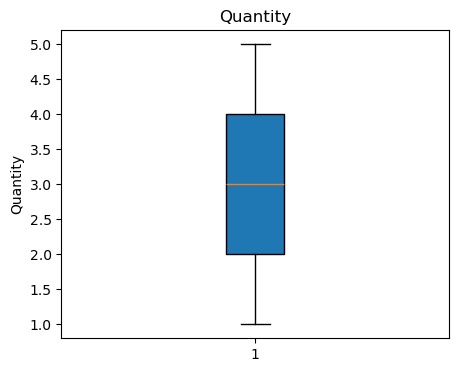

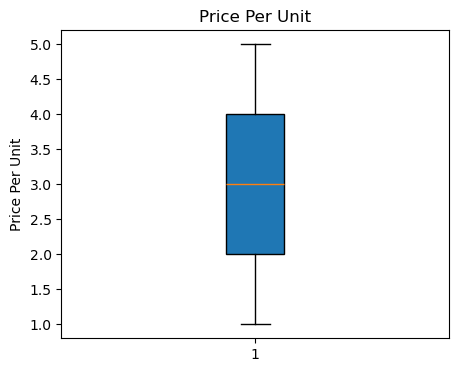

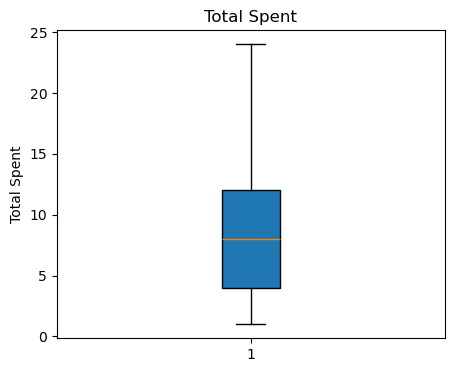

In [17]:
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col],patch_artist=True)
    plt.title(col)
    plt.ylabel(col)
    plt.show()

Boxplot shows that nomore outliers are present in dataset

## Produce a "before vs. after" summary table: null count, duplicate count, row count, and dtype accuracy — before and after cleaning

In [18]:
summary=pd.DataFrame({
    "Metric":["Row Count",
        "Duplicate Rows",
        "Total Missing Values",
        "Columns with Correct Data Types"],

    "Befor_Cleaning":[
        len(df_before),
        df_before.duplicated().sum(),
        df_before.isna().sum().sum(),
        df_before.dtypes.to_dict()
    ],

    "After_Cleaning":[
        len(df),
        df.duplicated().sum(),
        df.isna().sum().sum(),
        df.dtypes.to_dict()
    ]
})

summary

,Metric,Befor_Cleaning,After_Cleaning
0,Row Count,10000,9540
1,Duplicate Rows,0,0
2,Total Missing Values,6826,0
3,Columns with Correct Data Types,"{'Transaction ID': str, 'Item': str, 'Quantity...","{'Transaction ID': str, 'Item': str, 'Quantity..."


## Save the cleaned dataset to a new CSV file

In [19]:
# Save the cleaned dataset
df.to_csv("Cleaned_Cafe_Sales.csv", index=False)

print("Cleaned dataset saved successfully as 'Cleaned_Cafe_Sales.csv'")

Cleaned dataset saved successfully as 'Cleaned_Cafe_Sales.csv'


# Task 3 Complete